In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Données
X = np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]])
y = np.array([0,0,0,0,0,1,1,1,1,1])

# Distance euclidienne
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))

# KNN
def knn_predict(X_train, y_train, X_test, k=3):
    predictions = []

    for test_point in X_test:
        distances = []

        for i in range(len(X_train)):
            dist = euclidean_distance(test_point, X_train[i])
            distances.append((dist, y_train[i]))

        # Trier
        distances.sort(key=lambda x: x[0])

        # k voisins
        k_neighbors = distances[:k]

        # vote majoritaire
        labels = [label for _, label in k_neighbors]
        most_common = Counter(labels).most_common(1)[0][0]

        predictions.append(most_common)

    return np.array(predictions)

# Test
X_test = np.array([[3], [8]])
preds = knn_predict(X, y, X_test, k=3)
print("KNN prédictions :", preds)

KNN prédictions : [0 1]


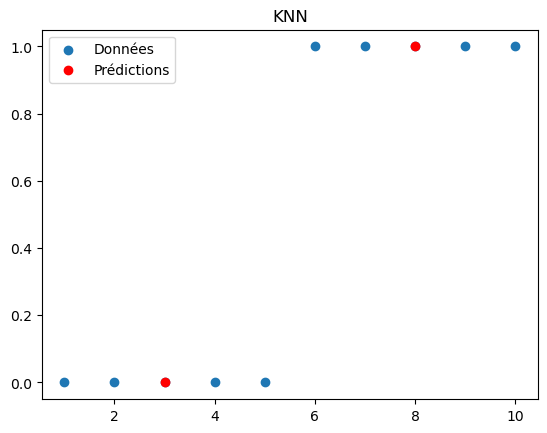

In [2]:
plt.scatter(X, y, label="Données")
plt.scatter(X_test, preds, color='red', label="Prédictions")
plt.legend()
plt.title("KNN")
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. DONNÉES
# ==========================================================
# IMPORTANT : SVM utilise des classes -1 et +1
X = np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]])
y = np.array([-1,-1,-1,-1,-1,1,1,1,1,1])


In [4]:
# ==========================================================
# 2. ENTRAÎNEMENT SVM
# ==========================================================
def fit_svm(X, y, lr=0.001, lambda_param=0.01, epochs=1000):
    """
    lr : learning rate
    lambda_param : régularisation
    epochs : nombre d'itérations
    """

    # Initialisation des paramètres
    w = 0   # poids
    b = 0   # biais

    # Descente de gradient
    for epoch in range(epochs):
        for i in range(len(X)):

            # Condition de marge
            condition = y[i] * (w * X[i] + b) >= 1

            if condition:
                # Pas d'erreur → seulement régularisation
                w -= lr * (2 * lambda_param * w)
            else:
                # Erreur → correction + régularisation
                w -= lr * (2 * lambda_param * w - y[i] * X[i])
                b -= lr * (-y[i])

    return w, b



In [5]:
# ==========================================================
# 3. ENTRAÎNEMENT
# ==========================================================
w, b = fit_svm(X, y)

In [6]:
# ==========================================================
# 4. PRÉDICTION
# ==========================================================
def predict_svm(X, w, b):
    """
    Utilise le signe pour classifier
    """
    return np.sign(w * X + b)


# Test
X_test = np.array([[3], [8]])
preds = predict_svm(X_test, w, b)

print("Prédictions SVM :", preds)

Prédictions SVM : [[-1.]
 [ 1.]]


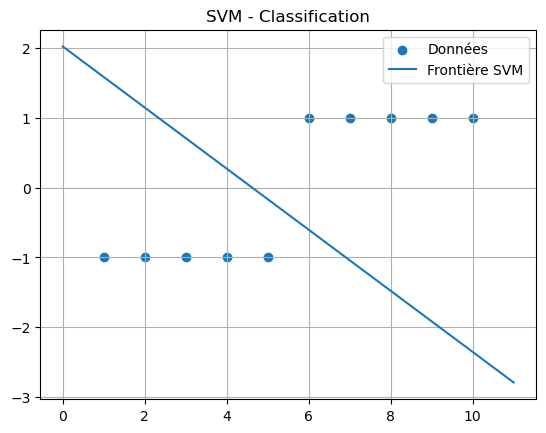

In [7]:
# ==========================================================
# 5. VISUALISATION
# ==========================================================
plt.scatter(X, y, label="Données")

# Frontière de décision
x_vals = np.linspace(0, 11, 100)
y_vals = -(w * x_vals + b)

plt.plot(x_vals, y_vals, label="Frontière SVM")

plt.title("SVM - Classification")
plt.legend()
plt.grid()
plt.show()